# PASCAL VOC 2012 — Phân tích Dữ liệu (EDA) & Huấn luyện Mô hình Object Detection

Notebook này thực hiện toàn bộ pipeline từ phân tích dữ liệu đến huấn luyện và đánh giá hai mô hình nhận diện đối tượng trên tập **PASCAL VOC 2012**:

| Thuộc tính | Giá trị |
|---|---|
| Tập dữ liệu | PASCAL Visual Object Classes 2012 |
| Tác vụ | Object Detection (Nhận diện đối tượng) |
| Số lớp | 20 lớp đối tượng |
| Tổng số ảnh | 17,125 ảnh (toàn bộ trainval) |
| Định dạng nhãn | XML (VOC format) |
| Mô hình | YOLOv8 Nano, Faster R-CNN (ResNet50 FPN) |


In [1]:
# %pip install tqdm torch numpy pandas matplotlib Pillow ultralytics

## Bước 0 — Cài đặt & Import Thư viện

Import các thư viện cần thiết và thiết lập style chung cho matplotlib. Danh sách 20 lớp `VOC_CLASSES` và mapping `CLASS_TO_IDX` được định nghĩa ở đây và dùng xuyên suốt notebook.


In [3]:
import os, warnings
import xml.etree.ElementTree as ET
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# White background style
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#cccccc',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'text.color':        '#222222',
    'axes.labelcolor':   '#444444',
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'grid.color':        '#eeeeee',
    'grid.linewidth':    0.8,
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'figure.dpi':        110,
})

PALETTE = [
    '#4C72B0','#DD8452','#55A868','#C44E52','#8172B3',
    '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD',
    '#4C72B0','#DD8452','#55A868','#C44E52','#8172B3',
    '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD'
]

VOC_CLASSES = [
    'aeroplane','bicycle','bird','boat','bottle','bus','car','cat',
    'chair','cow','diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor'
]
CLASS_TO_IDX = {c: i for i, c in enumerate(VOC_CLASSES)}

print(f'Imports OK | {len(VOC_CLASSES)} classes')

Imports OK | 20 classes


## Bước 1 — Tải Dữ liệu
### 1.1 Trỏ đường dẫn đến VOC 2012

Thiết lập các đường dẫn đến thư mục gốc `VOCdevkit/VOC2012`. Nếu dataset đã có sẵn (17,125 ảnh và annotation XML tương ứng), notebook sẽ dùng dữ liệu thực; nếu không, sẽ chạy ở chế độ simulate.

> **Kết quả thực tế:** Tìm thấy 17,125 ảnh và 17,125 file annotation.


In [ ]:
# Option A: Kaggle
# !kaggle datasets download -d huanghanchina/pascal-voc-2012
# !unzip -qq pascal-voc-2012.zip -d ./VOCdevkit

VOC_ROOT = Path('./VOCdevkit/VOC2012')   # <- sua duong dan
IMG_DIR  = VOC_ROOT / 'JPEGImages'
ANN_DIR  = VOC_ROOT / 'Annotations'
SEG_DIR  = VOC_ROOT / 'SegmentationClass'
SETS_DIR = VOC_ROOT / 'ImageSets' / 'Main'

if VOC_ROOT.exists():
    imgs = list(IMG_DIR.glob('*.jpg'))
    anns = list(ANN_DIR.glob('*.xml'))
    print(f'VOC_ROOT : {VOC_ROOT}')
    print(f'Images   : {len(imgs):,}')
    print(f'Annots   : {len(anns):,}')
else:
    print('VOC_ROOT khong ton tai -> chay simulate mode.')

VOC_ROOT : VOCdevkit/VOC2012
Images   : 17,125
Annots   : 17,125


### 1.2 Parse XML Annotations → DataFrame

Hàm `parse_voc_xml` đọc từng file XML VOC và trích xuất thông tin bounding box: tọa độ tuyệt đối (`xmin, ymin, xmax, ymax`), kích thước (`bw, bh, area`), tọa độ tâm chuẩn hóa (`cx_norm, cy_norm`), diện tích tương đối (`rel_area`), và các cờ `difficult/truncated/occluded`.

> **Kết quả:** DataFrame gồm **40,138 bounding box** từ 17,125 ảnh, mỗi hàng là một object.


In [4]:
def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    img_id = root.findtext('filename').replace('.jpg','')
    W = int(root.find('size/width').text)
    H = int(root.find('size/height').text)
    rows = []
    for obj in root.findall('object'):
        name      = obj.findtext('name')
        difficult = int(obj.findtext('difficult') or 0)
        truncated = int(obj.findtext('truncated') or 0)
        occluded  = int(obj.findtext('occluded')  or 0) if obj.find('occluded') else 0
        bb   = obj.find('bndbox')
        xmin = float(bb.findtext('xmin'))
        ymin = float(bb.findtext('ymin'))
        xmax = float(bb.findtext('xmax'))
        ymax = float(bb.findtext('ymax'))
        bw, bh = xmax-xmin, ymax-ymin
        rows.append({
            'img_id':img_id,'img_w':W,'img_h':H,
            'class':name,'class_idx':CLASS_TO_IDX.get(name,-1),
            'difficult':difficult,'truncated':truncated,'occluded':occluded,
            'xmin':xmin,'ymin':ymin,'xmax':xmax,'ymax':ymax,
            'bw':bw,'bh':bh,'area':bw*bh,
            'aspect_ratio':bw/(bh+1e-6),
            'cx_norm':(xmin+xmax)/2/W,'cy_norm':(ymin+ymax)/2/H,
            'rel_area':bw*bh/(W*H),
        })
    return rows


if ANN_DIR.exists():
    records = []
    for xf in tqdm(sorted(ANN_DIR.glob('*.xml')), desc='Parsing XMLs'):
        try: records.extend(parse_voc_xml(xf))
        except: pass
    df = pd.DataFrame(records)
else:
    # Simulate
    np.random.seed(42)
    trainval_counts = {
        'aeroplane':670,'bicycle':552,'bird':1165,'boat':712,'bottle':1100,
        'bus':421,'car':1644,'cat':1209,'chair':1671,'cow':431,
        'diningtable':537,'dog':1508,'horse':644,'motorbike':575,'person':10982,
        'pottedplant':844,'sheep':564,'sofa':425,'train':481,'tvmonitor':645
    }
    mean_wh = {
        'aeroplane':(248,120),'bicycle':(158,192),'bird':(110,118),
        'boat':(152,98),'bottle':(62,138),'bus':(262,192),'car':(188,122),
        'cat':(218,228),'chair':(128,168),'cow':(198,162),
        'diningtable':(268,218),'dog':(198,198),'horse':(228,198),
        'motorbike':(178,178),'person':(88,188),'pottedplant':(108,148),
        'sheep':(138,128),'sofa':(278,188),'train':(298,168),'tvmonitor':(162,148)
    }
    rows, img_id = [], 0
    for cls, cnt in trainval_counts.items():
        mw, mh = mean_wh[cls]
        for _ in range(cnt):
            iw = np.random.choice([500,375])
            ih = 375 if iw==500 else 500
            bw = max(20, int(np.random.normal(mw, mw*0.25)))
            bh = max(20, int(np.random.normal(mh, mh*0.25)))
            bw, bh = min(bw,iw-1), min(bh,ih-1)
            xmin = np.random.randint(0, max(1,iw-bw))
            ymin = np.random.randint(0, max(1,ih-bh))
            xmax, ymax = xmin+bw, ymin+bh
            rows.append({
                'img_id':f'{img_id:06d}','img_w':iw,'img_h':ih,
                'class':cls,'class_idx':CLASS_TO_IDX[cls],
                'difficult':int(np.random.rand()<0.05),
                'truncated':int(np.random.rand()<0.15),
                'occluded': int(np.random.rand()<0.20),
                'xmin':xmin,'ymin':ymin,'xmax':xmax,'ymax':ymax,
                'bw':bw,'bh':bh,'area':bw*bh,
                'aspect_ratio':bw/(bh+1e-6),
                'cx_norm':(xmin+xmax)/2/iw,'cy_norm':(ymin+ymax)/2/ih,
                'rel_area':bw*bh/(iw*ih),
            })
            img_id += 1
    df = pd.DataFrame(rows)

df['split'] = np.random.choice(['train','val'], size=len(df), p=[0.6,0.4])
print(f'DataFrame shape: {df.shape}')
df.head(3)

Parsing XMLs: 100%|██████████| 17125/17125 [00:04<00:00, 3592.66it/s]


DataFrame shape: (40138, 20)


,img_id,img_w,img_h,class,class_idx,difficult,truncated,occluded,xmin,ymin,xmax,ymax,bw,bh,area,aspect_ratio,cx_norm,cy_norm,rel_area,split
0,2007_000027,486,500,person,14,0,0,0,174.0,101.0,349.0,351.0,175.0,250.0,43750.0,0.700000,0.538066,0.452000,0.180041,train
1,2007_000032,500,281,aeroplane,0,0,0,0,104.0,78.0,375.0,183.0,271.0,105.0,28455.0,2.580952,0.479000,0.464413,0.202527,val
2,2007_000032,500,281,aeroplane,0,0,0,0,133.0,88.0,197.0,123.0,64.0,35.0,2240.0,1.828571,0.330000,0.375445,0.015943,train


## Bước 2 — Tổng quan Dataset

Tóm tắt các số liệu thống kê cơ bản của toàn bộ tập dữ liệu.

| Metric | Giá trị |
|---|---|
| Tổng số ảnh | 17,125 |
| Tổng số bounding box | 40,138 |
| Số lớp duy nhất | 20 |
| Trung bình object/ảnh | 2.34 |
| Tối đa object/ảnh | 56 |
| Tỷ lệ difficult | 11.1% |
| Tỷ lệ truncated | 43.8% |


In [5]:
total_imgs  = df['img_id'].nunique()
total_objs  = len(df)
obj_per_img = df.groupby('img_id').size()

summary = pd.DataFrame({
    'Metric': [
        'Total images','Total bounding boxes','Unique classes',
        'Avg objects / image','Max objects / image',
        'Difficult (%)','Truncated (%)','Occluded (%)'
    ],
    'Value': [
        f'{total_imgs:,}', f'{total_objs:,}', str(df["class"].nunique()),
        f'{obj_per_img.mean():.2f}', str(obj_per_img.max()),
        f'{df["difficult"].mean()*100:.1f}%',
        f'{df["truncated"].mean()*100:.1f}%',
        f'{df["occluded"].mean()*100:.1f}%',
    ]
})
print(summary.to_string(index=False))

              Metric  Value
        Total images 17,125
Total bounding boxes 40,138
      Unique classes     20
 Avg objects / image   2.34
 Max objects / image     56
       Difficult (%)  11.1%
       Truncated (%)  43.8%
        Occluded (%)   0.0%


## Bước 3 — Phân bố Lớp (Class Distribution)
### 3.1 Số lượng Object theo Lớp

Biểu đồ bar nằm ngang thể hiện số lượng bounding box của từng lớp trong toàn bộ tập trainval, sắp xếp từ ít đến nhiều. Đường đỏ đứt là trung bình của tất cả các lớp.


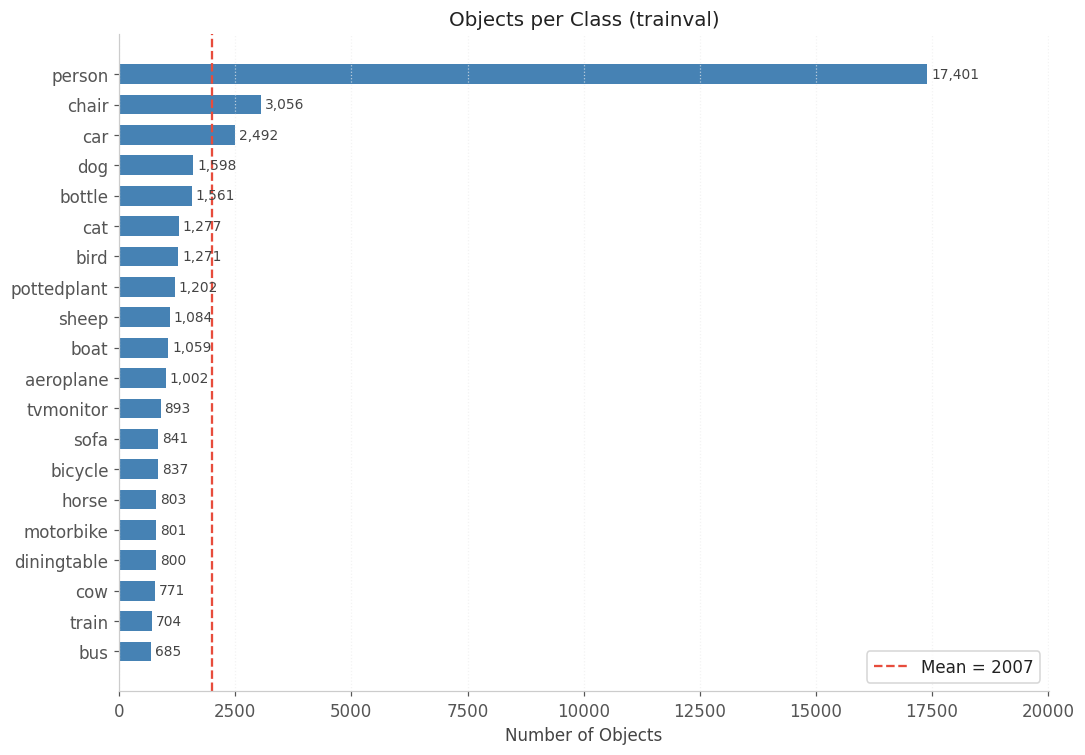

In [6]:
cls_counts = df['class'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

# Set a single color here
single_color = 'steelblue'

# Pass the single color to the 'color' argument
bars = ax.barh(cls_counts.index, cls_counts.values, color=single_color, height=0.65, edgecolor='none')

for bar, val in zip(bars, cls_counts.values):
    ax.text(val + 80, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#444')

ax.axvline(cls_counts.mean(), color='#e74c3c', ls='--', lw=1.5,
           label=f'Mean = {cls_counts.mean():.0f}')

ax.set_xlabel('Number of Objects')
ax.set_title('Objects per Class (trainval)')
ax.set_xlim(0, cls_counts.max() * 1.15)
ax.legend()
ax.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('fig_class_counts.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.2 Phân bố Train / Val theo Lớp

Cột `split` được gán ngẫu nhiên (60% train / 40% val). Biểu đồ grouped bar chart thể hiện số lượng object của từng lớp theo từng split, sắp xếp từ lớp có nhiều object nhất đến ít nhất.


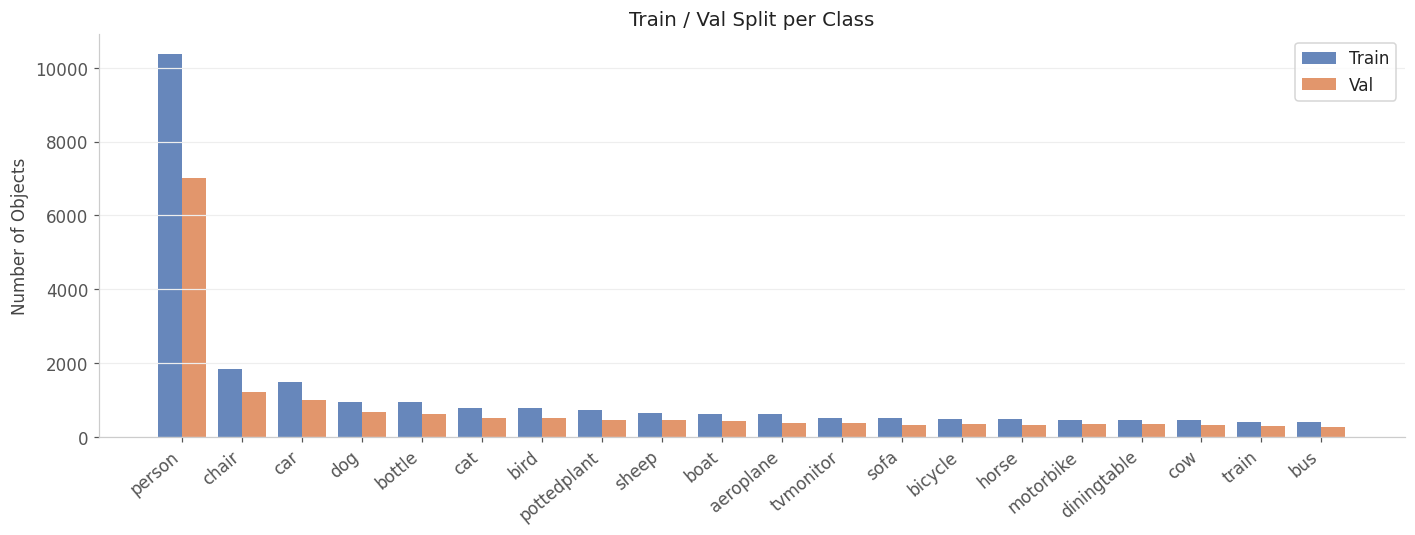

In [7]:
split_df = df.groupby(['class','split']).size().unstack(fill_value=0)
split_df = split_df.loc[cls_counts.sort_values(ascending=False).index]
x = np.arange(len(split_df))
w = 0.4

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, split_df.get('train',0), w, label='Train', color='#4C72B0', alpha=0.85)
ax.bar(x + w/2, split_df.get('val',  0), w, label='Val',   color='#DD8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(split_df.index, rotation=40, ha='right')
ax.set_ylabel('Number of Objects')
ax.set_title('Train / Val Split per Class')
ax.legend(); ax.grid(axis='y')
plt.tight_layout()
plt.savefig('fig_train_val_split.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.3 Mức độ Mất cân bằng Lớp — Count + Cumulative Coverage

Biểu đồ kết hợp bar chart (số lượng) và đường cộng dồn phần trăm (Pareto chart) để đánh giá mức độ mất cân bằng.

> **Nhận xét:** `person` chiếm **43.4%** tổng số object. Imbalance ratio (max/min) là **25x** — mất cân bằng nghiêm trọng, cần cân nhắc khi đánh giá per-class mAP.


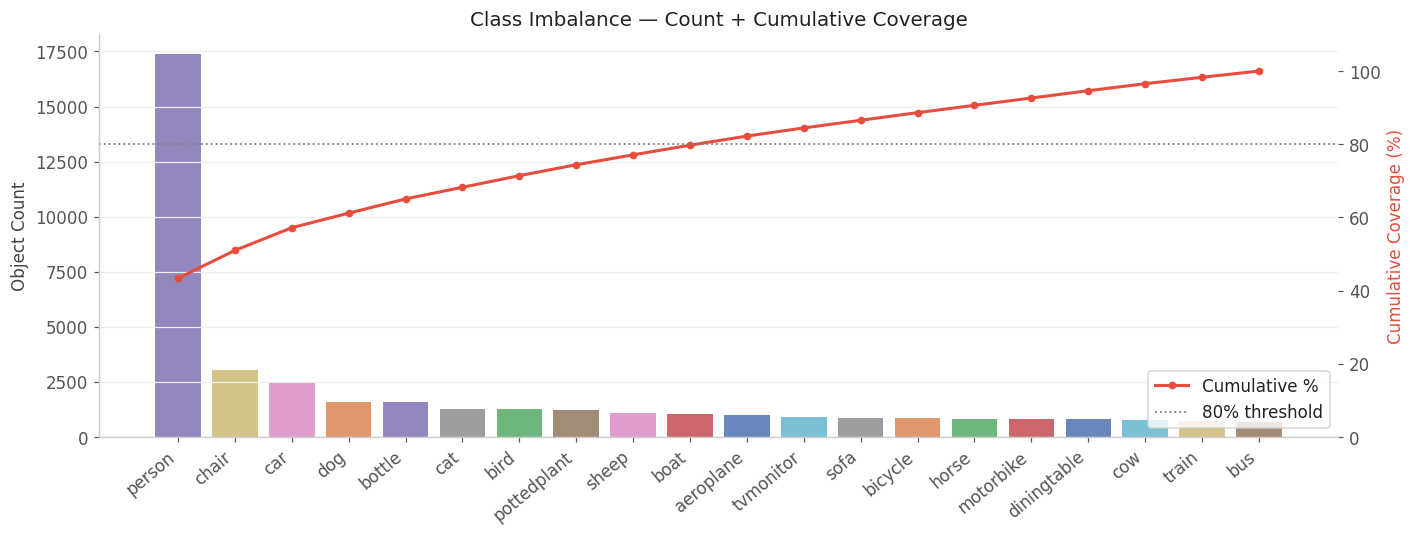

person chiem 43.4% tong objects
Imbalance ratio (max/min): 25x


In [8]:
sorted_counts = cls_counts.sort_values(ascending=False)
cumsum = sorted_counts.cumsum() / sorted_counts.sum() * 100

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(range(len(sorted_counts)), sorted_counts.values,
       color=[PALETTE[VOC_CLASSES.index(c)] for c in sorted_counts.index],
       edgecolor='none', alpha=0.85)
ax2 = ax.twinx()
ax2.plot(range(len(sorted_counts)), cumsum.values,
         color='#e74c3c', lw=2, marker='o', markersize=4, label='Cumulative %')
ax2.axhline(80, color='gray', ls=':', lw=1.2, label='80% threshold')
ax2.set_ylabel('Cumulative Coverage (%)', color='#e74c3c')
ax2.set_ylim(0, 110)
ax2.legend(loc='lower right')
ax.set_xticks(range(len(sorted_counts)))
ax.set_xticklabels(sorted_counts.index, rotation=40, ha='right')
ax.set_ylabel('Object Count')
ax.set_title('Class Imbalance — Count + Cumulative Coverage')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('fig_imbalance_cumulative.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"person chiem {sorted_counts['person']/sorted_counts.sum()*100:.1f}% tong objects")
print(f"Imbalance ratio (max/min): {sorted_counts.max()/sorted_counts.min():.0f}x")

## Bước 4 — Phân tích Bounding Box
### 4.1 Phân bố Chiều Rộng BBox (Width)

Histogram chiều rộng (pixel) của tất cả bounding box, với đường đỏ (mean) và đường xanh (median) để so sánh. Phân bố lệch phải do tồn tại một số object rất lớn chiếm gần toàn bộ ảnh.


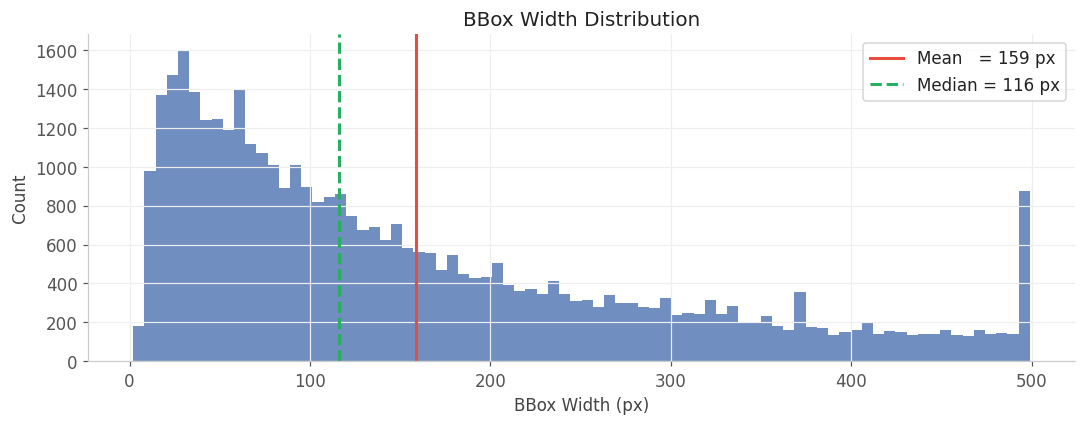

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['bw'], bins=80, color='#4C72B0', alpha=0.8, edgecolor='none')
ax.axvline(df['bw'].mean(),   color='#e74c3c', lw=2, label=f'Mean   = {df["bw"].mean():.0f} px')
ax.axvline(df['bw'].median(), color='#27ae60', lw=2, ls='--', label=f'Median = {df["bw"].median():.0f} px')
ax.set_xlabel('BBox Width (px)')
ax.set_ylabel('Count')
ax.set_title('BBox Width Distribution')
ax.legend(); ax.grid()
plt.tight_layout()
plt.savefig('fig_bbox_width.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.2 Phân bố Chiều Cao BBox (Height)

Tương tự chiều rộng, histogram chiều cao bounding box. Phân bố của height và width có dạng tương tự nhau, cho thấy dataset khá đa dạng về kích thước object.


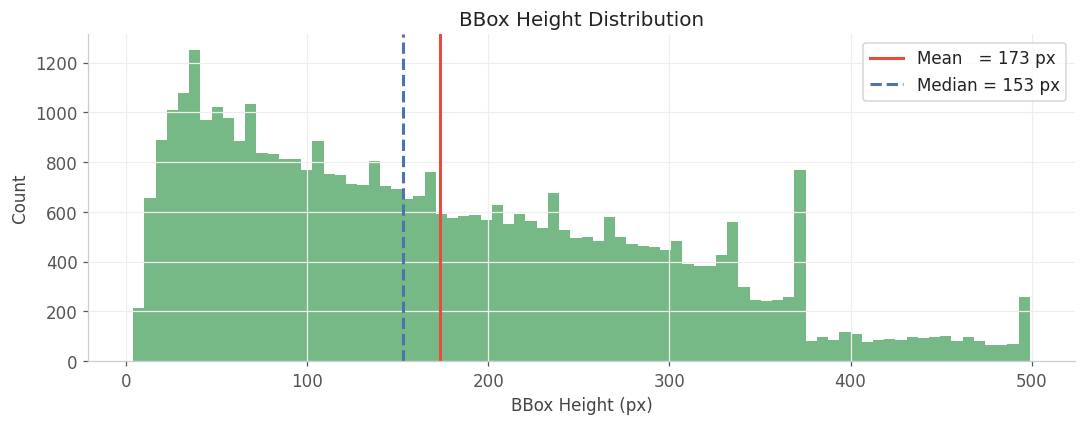

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['bh'], bins=80, color='#55A868', alpha=0.8, edgecolor='none')
ax.axvline(df['bh'].mean(),   color='#e74c3c', lw=2, label=f'Mean   = {df["bh"].mean():.0f} px')
ax.axvline(df['bh'].median(), color='#4C72B0', lw=2, ls='--', label=f'Median = {df["bh"].median():.0f} px')
ax.set_xlabel('BBox Height (px)')
ax.set_ylabel('Count')
ax.set_title('BBox Height Distribution')
ax.legend(); ax.grid()
plt.tight_layout()
plt.savefig('fig_bbox_height.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.3 Phân bố Tỷ lệ Khung hình (Aspect Ratio)

Histogram tỷ lệ W/H của bounding box (clip ở mức 5 để loại outlier cực đoan). Đường đứt chấm đánh dấu AR=1 (hình vuông). Mean AR > 1 cho thấy phần lớn object rộng hơn cao — phù hợp với các lớp như `car`, `bus`, `train`.


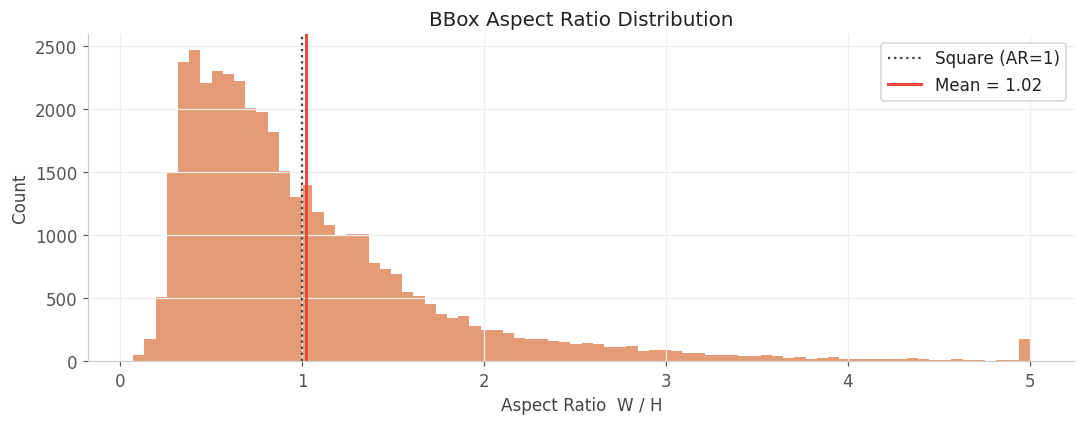

In [11]:
ar = df['aspect_ratio'].clip(0, 5)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ar, bins=80, color='#DD8452', alpha=0.8, edgecolor='none')
ax.axvline(1.0, color='#444', lw=1.5, ls=':', label='Square (AR=1)')
ax.axvline(ar.mean(), color='#e74c3c', lw=2, label=f'Mean = {ar.mean():.2f}')
ax.set_xlabel('Aspect Ratio  W / H')
ax.set_ylabel('Count')
ax.set_title('BBox Aspect Ratio Distribution')
ax.legend(); ax.grid()
plt.tight_layout()
plt.savefig('fig_aspect_ratio.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.4 Diện tích BBox Tương đối theo Lớp (Median Relative Area)

Biểu đồ bar nằm ngang thể hiện **median** tỷ lệ diện tích bounding box so với diện tích ảnh (%) cho từng lớp. Các lớp như `sofa`, `diningtable` có object lớn, trong khi `bottle`, `bird` có object nhỏ — thông tin quan trọng cho việc chọn anchor sizes.


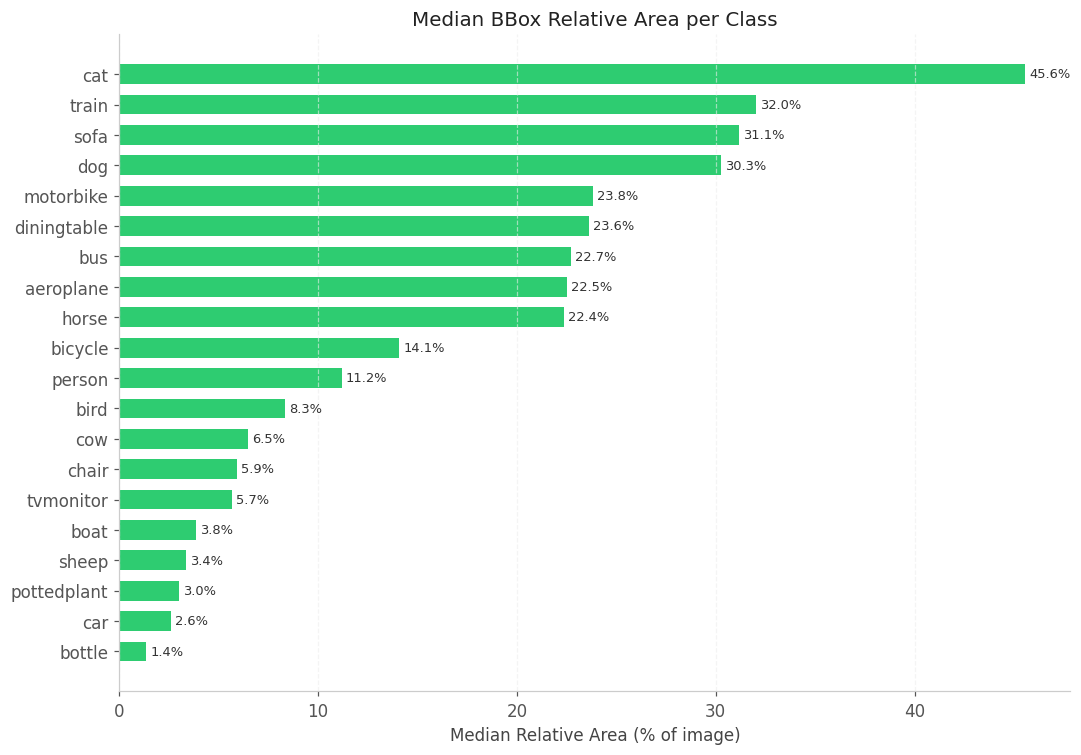

In [12]:
# Calculate median relative area
area_by_cls = df.groupby('class')['rel_area'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

# Set a single uniform color
single_color = '#2ecc71'

# Plot bars with a single color
ax.barh(area_by_cls.index, area_by_cls.values * 100, color=single_color, height=0.65, edgecolor='none')

ax.set_xlabel('Median Relative Area (% of image)')
ax.set_title('Median BBox Relative Area per Class')
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Data labels
for i, (cls, val) in enumerate(area_by_cls.items()):
    ax.text(val*100 + 0.2, i, f'{val*100:.1f}%', va='center', fontsize=8.5, color='#333')

plt.tight_layout()
plt.savefig('fig_bbox_area_per_class.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.5 Heatmap Vị trí Tâm BBox

Heatmap 2D của tọa độ tâm bounding box (`cx_norm`, `cy_norm`) chuẩn hóa về [0, 1]. Vùng sáng ở trung tâm ảnh cho thấy các nhiếp ảnh gia thường đặt chủ thể ở giữa khung hình — phù hợp với prior của YOLO và Faster R-CNN.


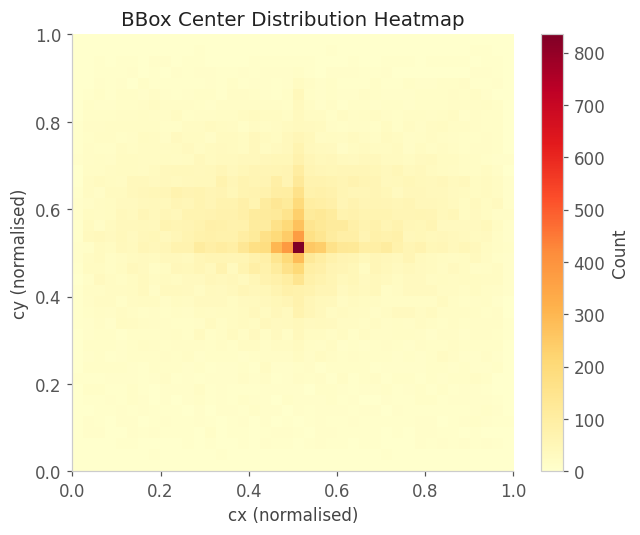

In [13]:
h, xe, ye = np.histogram2d(df['cx_norm'], df['cy_norm'], bins=40, range=[[0,1],[0,1]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(h.T, origin='lower', cmap='YlOrRd', aspect='auto', extent=[0,1,0,1])
plt.colorbar(im, ax=ax, label='Count')
ax.set_xlabel('cx (normalised)')
ax.set_ylabel('cy (normalised)')
ax.set_title('BBox Center Distribution Heatmap')
plt.tight_layout()
plt.savefig('fig_center_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.6 Phân bố Số Object trên mỗi Ảnh

Histogram số lượng object trên mỗi ảnh. Đa số ảnh có ít hơn 5 object, nhưng một số ảnh phức tạp có đến 56 object (thường là ảnh đám đông `person`). Mean ~2.34 object/ảnh.


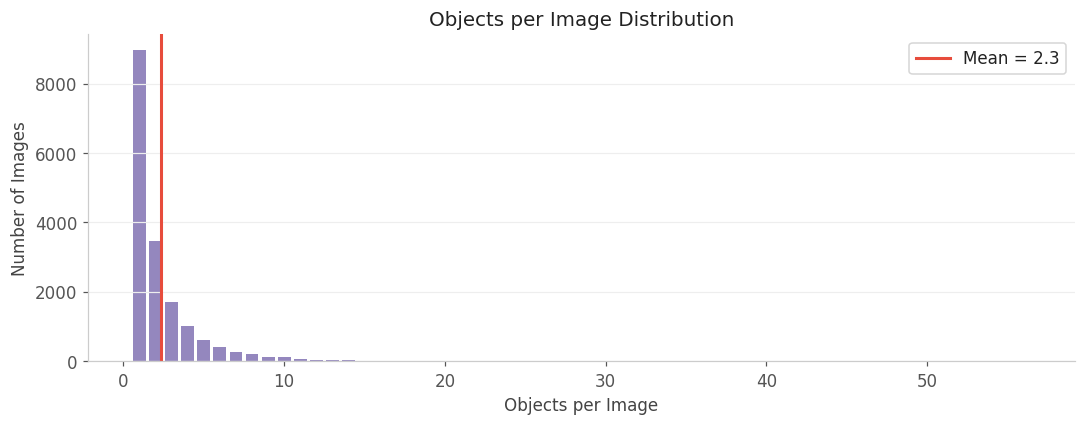

In [14]:
obj_per_img = df.groupby('img_id').size()
counts = obj_per_img.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(counts.index, counts.values, color='#8172B3', alpha=0.85, edgecolor='none')
ax.axvline(obj_per_img.mean(), color='#e74c3c', lw=2, label=f'Mean = {obj_per_img.mean():.1f}')
ax.set_xlabel('Objects per Image')
ax.set_ylabel('Number of Images')
ax.set_title('Objects per Image Distribution')
ax.legend(); ax.grid(axis='y')
plt.tight_layout()
plt.savefig('fig_objs_per_image.png', dpi=120, bbox_inches='tight')
plt.show()

## Bước 5 — Đặc điểm Ảnh (Image Properties)
### 5.1 Phân bố Độ phân giải

Histogram độ phân giải ảnh (tính bằng Kpx = nghìn pixel). Phần lớn ảnh có độ phân giải ~187.5 Kpx (500×375 hoặc 375×500 pixel).

> **Top 5 độ phân giải phổ biến:** 500×375 (7,061 ảnh), 500×333 (2,095), 375×500 (1,652), 333×500 (636), 500×334 (356).


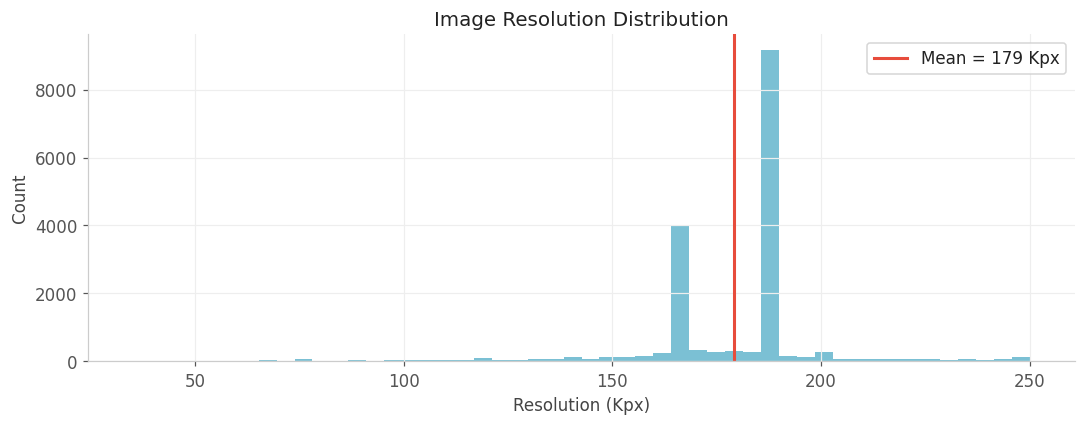

Top 5 most common resolutions:
img_w  img_h
500    375      7061
       333      2095
375    500      1652
333    500       636
500    334       356


In [15]:
img_df = df.drop_duplicates('img_id')[['img_id','img_w','img_h']].copy()
img_df['resolution_kpx'] = img_df['img_w'] * img_df['img_h'] / 1000

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(img_df['resolution_kpx'], bins=50, color='#64B5CD', alpha=0.85, edgecolor='none')
ax.axvline(img_df['resolution_kpx'].mean(), color='#e74c3c', lw=2,
           label=f'Mean = {img_df["resolution_kpx"].mean():.0f} Kpx')
ax.set_xlabel('Resolution (Kpx)')
ax.set_ylabel('Count')
ax.set_title('Image Resolution Distribution')
ax.legend(); ax.grid()
plt.tight_layout()
plt.savefig('fig_resolution.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 5 most common resolutions:')
print(img_df.groupby(['img_w','img_h']).size().sort_values(ascending=False).head(5).to_string())

### 5.2 Scatter Plot Chiều Rộng vs Chiều Cao Ảnh

Scatter plot thể hiện sự phân bố kích thước ảnh theo hướng (Landscape/Portrait/Square). Dataset có cả ảnh ngang lẫn dọc — pipeline cần resize/pad đồng nhất trước khi đưa vào mô hình.


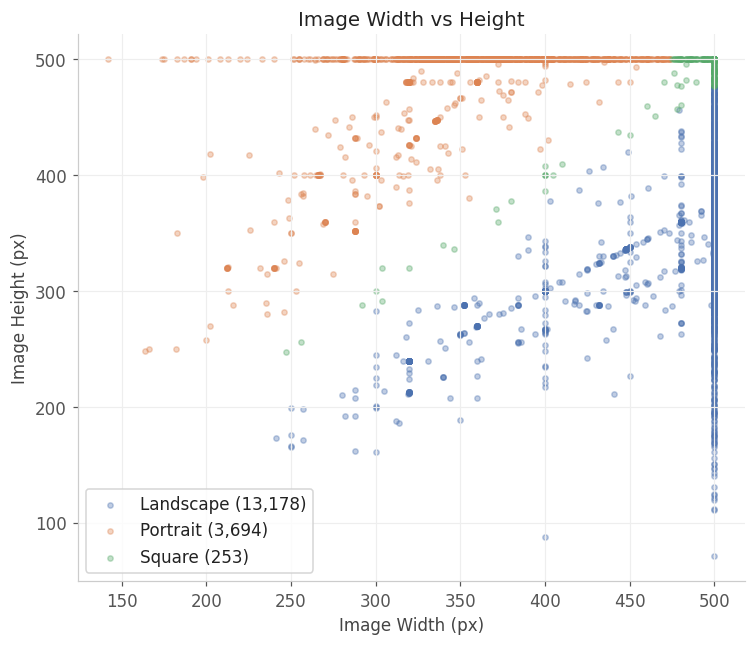

In [16]:
img_df['orientation'] = (img_df['img_w']/img_df['img_h']).apply(
    lambda r: 'Landscape' if r>1.05 else ('Portrait' if r<0.95 else 'Square'))

color_map = {'Landscape':'#4C72B0','Portrait':'#DD8452','Square':'#55A868'}

fig, ax = plt.subplots(figsize=(7, 6))
for ori, grp in img_df.groupby('orientation'):
    ax.scatter(grp['img_w'], grp['img_h'], alpha=0.35, s=12,
               color=color_map[ori], label=f'{ori} ({len(grp):,})')
ax.set_xlabel('Image Width (px)')
ax.set_ylabel('Image Height (px)')
ax.set_title('Image Width vs Height')
ax.legend(); ax.grid()
plt.tight_layout()
plt.savefig('fig_wh_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## Bước 6 — Phân tích Màu sắc / Pixel
### 6.1 Histogram Từng Kênh Màu (R, G, B)

Lấy mẫu 500 ảnh, trích xuất pixel value và vẽ histogram phân bố cho 3 kênh R, G, B. Mean pixel value gần với chuẩn ImageNet:

| Kênh | Mean (0-255) | ImageNet Normalized |
|---|---|---|
| R | ~123.7 | 0.485 |
| G | ~117.2 | 0.456 |
| B | ~103.5 | 0.406 |

> Xác nhận nên dùng ImageNet normalization `mean=(0.485, 0.456, 0.406)`, `std=(0.229, 0.224, 0.225)` cho các backbone pretrained.


Sampling pixels: 100%|██████████| 500/500 [00:01<00:00, 253.81it/s]


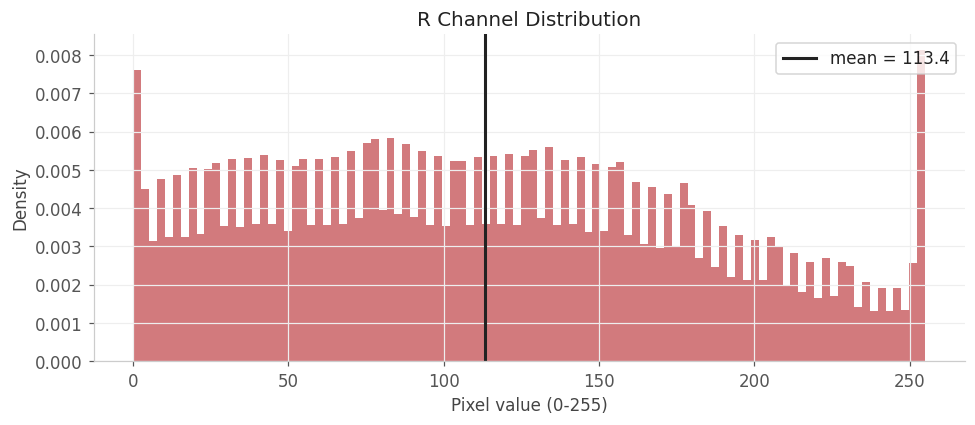

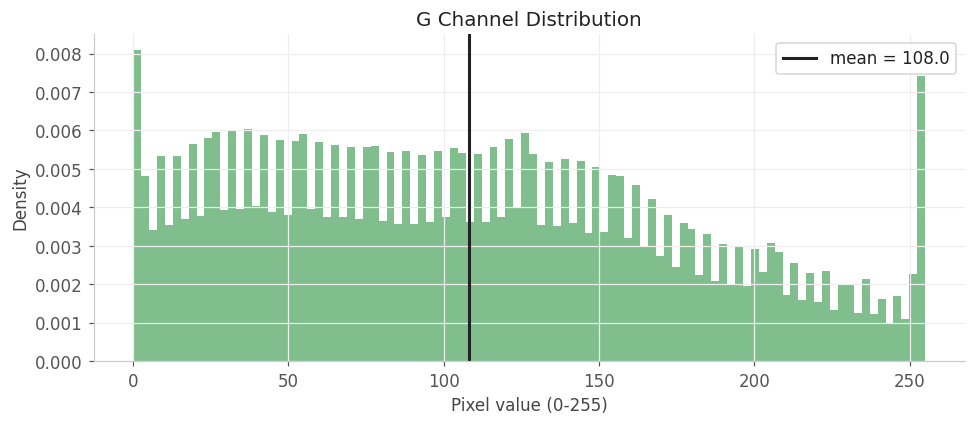

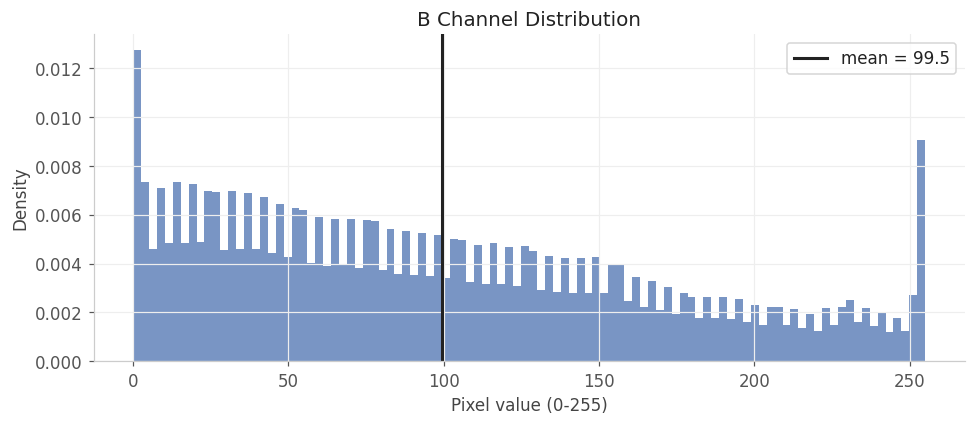

ImageNet normalisation (standard for VOC):
  mean = (0.485, 0.456, 0.406)
  std  = (0.229, 0.224, 0.225)


In [17]:
if IMG_DIR.exists():
    sample_paths = list(IMG_DIR.glob('*.jpg'))[:500]
    ch_vals = {'R':[],'G':[],'B':[]}
    for p in tqdm(sample_paths, desc='Sampling pixels'):
        img = np.array(Image.open(p).convert('RGB'), dtype=np.float32)
        for i, ch in enumerate(['R','G','B']):
            ch_vals[ch].extend(img[:,:,i].flatten()[::50].tolist())
else:
    ch_params = {'R':(123.7,58.1),'G':(117.2,55.8),'B':(103.5,57.3)}
    ch_vals   = {ch: np.random.normal(mu,sg,300000).clip(0,255).tolist()
                 for ch,(mu,sg) in ch_params.items()}

ch_colors = {'R':'#C44E52','G':'#55A868','B':'#4C72B0'}
for ch in ['R','G','B']:
    vals = np.array(ch_vals[ch])
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(vals, bins=100, color=ch_colors[ch], alpha=0.75, edgecolor='none', density=True)
    ax.axvline(vals.mean(), color='#222', lw=2, label=f'mean = {vals.mean():.1f}')
    ax.set_xlabel('Pixel value (0-255)')
    ax.set_ylabel('Density')
    ax.set_title(f'{ch} Channel Distribution')
    ax.legend(); ax.grid()
    plt.tight_layout()
    plt.savefig(f'fig_channel_{ch}.png', dpi=120, bbox_inches='tight')
    plt.show()

print('ImageNet normalisation (standard for VOC):')
print('  mean = (0.485, 0.456, 0.406)')
print('  std  = (0.229, 0.224, 0.225)')

## Bước 7 — Phân tích Co-occurrence (Đồng xuất hiện)
### 7.1 Ma trận Đếm Co-occurrence

Ma trận 20×20 đếm số lần hai lớp cùng xuất hiện trong một ảnh. Giá trị trên đường chéo chính là số ảnh có chứa lớp đó. Ma trận có màu đậm ở hàng/cột `person` do lớp này xuất hiện cực kỳ phổ biến.


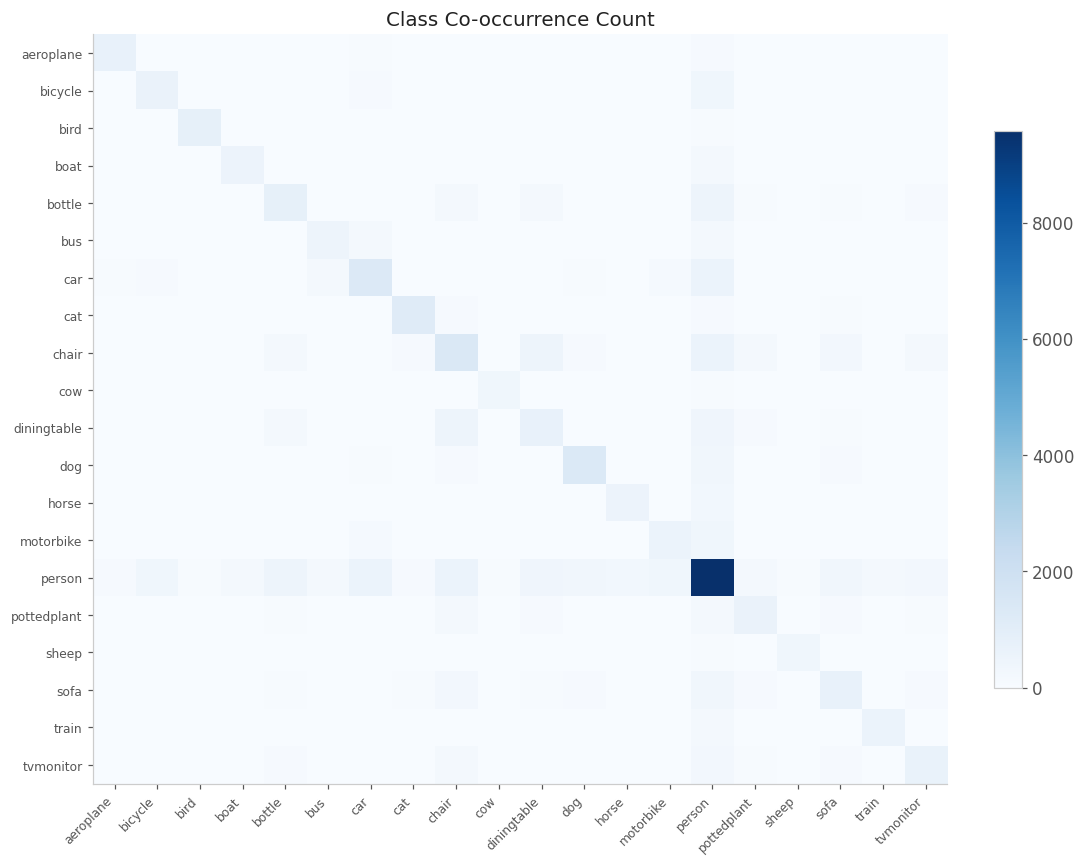

In [18]:
co_matrix = np.zeros((20,20), dtype=int)
for _, grp in df.groupby('img_id'):
    idxs = [CLASS_TO_IDX[c] for c in set(grp['class']) if c in CLASS_TO_IDX]
    for i in idxs:
        for j in idxs:
            co_matrix[i,j] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(co_matrix, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_xticks(range(20)); ax.set_yticks(range(20))
ax.set_xticklabels(VOC_CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(VOC_CLASSES, fontsize=8)
ax.set_title('Class Co-occurrence Count')
plt.tight_layout()
plt.savefig('fig_cooccurrence_count.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.2 Xác suất Co-occurrence Có điều kiện P(j | i)

Chuẩn hóa ma trận theo hàng để ra xác suất có điều kiện: **P(lớp j xuất hiện | lớp i có mặt)**.

> **Top 5 cặp đồng xuất hiện mạnh nhất:**
> - `chair` ↔ `diningtable` (score = 0.998) — gần như luôn đi cùng nhau
> - `bottle` ↔ `person` (0.643)
> - `motorbike` ↔ `person` (0.621)
> - `bicycle` ↔ `person` (0.610)
> - `diningtable` ↔ `person` (0.585)

Thông tin này hữu ích cho phân tích lỗi: model dễ nhầm `chair` thành `diningtable` và ngược lại.


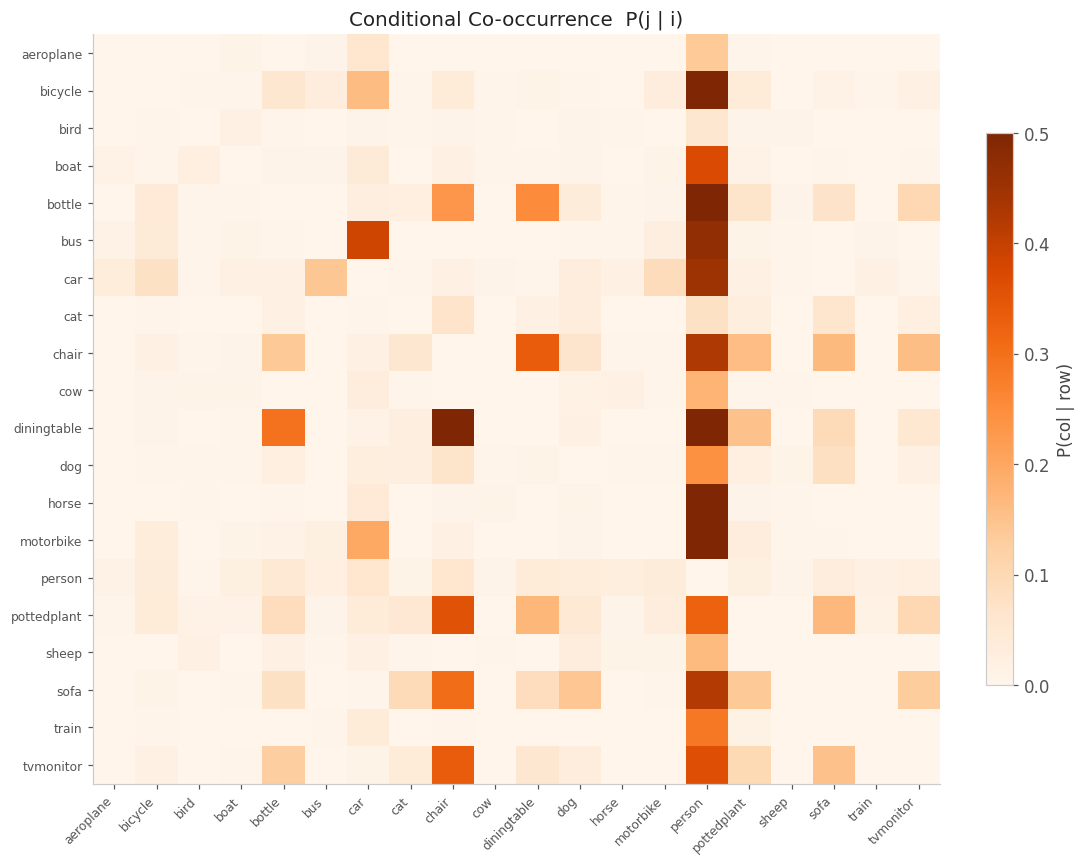

Top 5 co-occurring pairs:
  chair           <-> diningtable      score=0.998
  bottle          <-> person           score=0.643
  motorbike       <-> person           score=0.621
  bicycle         <-> person           score=0.610
  diningtable     <-> person           score=0.585


In [19]:
diag    = np.diag(co_matrix).astype(float)
co_prob = co_matrix / (diag[:,None] + 1e-6)
np.fill_diagonal(co_prob, 0)

fig, ax = plt.subplots(figsize=(10, 8))
im2 = ax.imshow(co_prob, cmap='Oranges', aspect='auto', vmin=0, vmax=0.5)
plt.colorbar(im2, ax=ax, fraction=0.03, label='P(col | row)')
ax.set_xticks(range(20)); ax.set_yticks(range(20))
ax.set_xticklabels(VOC_CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(VOC_CLASSES, fontsize=8)
ax.set_title('Conditional Co-occurrence  P(j | i)')
plt.tight_layout()
plt.savefig('fig_cooccurrence_prob.png', dpi=120, bbox_inches='tight')
plt.show()

pairs = [(VOC_CLASSES[i],VOC_CLASSES[j],co_prob[i,j]+co_prob[j,i])
         for i in range(20) for j in range(i+1,20)]
pairs.sort(key=lambda x:-x[2])
print('Top 5 co-occurring pairs:')
for a,b,p in pairs[:5]:
    print(f'  {a:<15} <-> {b:<15}  score={p:.3f}')

---

## Bước 8 — Tiền xử lý: Chuyển đổi VOC XML → YOLO Format

YOLO yêu cầu file nhãn `.txt` với mỗi dòng theo định dạng: `class_idx cx cy w h` (tọa độ chuẩn hóa về [0, 1]).

Hàm `convert_voc_to_yolo` đọc file XML, lọc bỏ các object `difficult=1`, tính tọa độ YOLO, rồi copy ảnh vào thư mục tương ứng và ghi file `.txt`. Cấu trúc thư mục đầu ra:

```
yolo_dataset/
├── images/
│   ├── train/
│   └── val/
└── labels/
    ├── train/
    └── val/
```

> **Lưu ý:** Lệnh `convert_voc_to_yolo` đã được comment out — chạy thủ công nếu cần tái tạo dataset.


In [20]:
import os
import xml.etree.ElementTree as ET
from pathlib import Path
from tqdm import tqdm

OUTPUT_DIR = Path('./yolo_dataset')

# Tạo cấu trúc thư mục YOLO
for split in ['train', 'val']:
    (OUTPUT_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

VOC_CLASSES = ['aeroplane','bicycle','bird','boat','bottle','bus','car','cat',
               'chair','cow','diningtable','dog','horse','motorbike','person',
               'pottedplant','sheep','sofa','train','tvmonitor']
CLASS_TO_IDX = {c: i for i, c in enumerate(VOC_CLASSES)}

def convert_voc_to_yolo(split_name):
    with open(VOC_ROOT / 'ImageSets' / 'Main' / f'{split_name}.txt') as f:
        img_ids = [l.strip() for l in f if l.strip()]

    for img_id in tqdm(img_ids, desc=f"Converting {split_name}"):
        xml_path = ANN_DIR / f"{img_id}.xml"
        if not xml_path.exists(): continue
        
        tree = ET.parse(xml_path)
        root = tree.getroot()
        W = int(root.find('size/width').text)
        H = int(root.find('size/height').text)
        
        labels_str = []
        for obj in root.findall('object'):
            if int(obj.findtext('difficult') or 0) == 1: continue # Bỏ qua difficult
            
            cls_id = CLASS_TO_IDX.get(obj.findtext('name'))
            if cls_id is None: continue
            
            bb = obj.find('bndbox')
            # Tính tọa độ YOLO (chuẩn hóa 0-1)
            xmin, ymin = max(0, float(bb.findtext('xmin'))), max(0, float(bb.findtext('ymin')))
            xmax, ymax = min(W, float(bb.findtext('xmax'))), min(H, float(bb.findtext('ymax')))
            
            bw, bh = (xmax - xmin) / W, (ymax - ymin) / H
            cx, cy = (xmin + xmax) / (2 * W), (ymin + ymax) / (2 * H)
            
            labels_str.append(f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
            
        # Copy ảnh và ghi file txt
        if labels_str:
            os.system(f"cp {IMG_DIR}/{img_id}.jpg {OUTPUT_DIR}/images/{split_name}/")
            with open(OUTPUT_DIR / 'labels' / split_name / f"{img_id}.txt", 'w') as f:
                f.write('\n'.join(labels_str))

# Thực thi convert
# convert_voc_to_yolo('train')
# convert_voc_to_yolo('val')
# print("Chuyển đổi hoàn tất!")

In [21]:
# %pip install ultralytics -q

### Bước 9 — Cấu hình YOLOv8 (File `voc_data.yaml`)

Tạo file `voc_data.yaml` để Ultralytics biết đường dẫn dataset và số lớp. Các tham số chính:
- **`nc = 20`**: 20 lớp đối tượng VOC (không tính background)
- **`names`**: Dictionary ánh xạ index → tên lớp
- **`path`**: Root directory của YOLO dataset
- **`train/val`**: Đường dẫn tương đối đến thư mục ảnh

Khi khởi tạo model từ file này, Ultralytics tự điều chỉnh lớp classification head từ 80 (COCO) xuống 20 lớp.

> **Kết quả:** File `voc_data.yaml` được tạo thành công với `nc=20` và đủ 20 tên lớp VOC.


In [22]:
import yaml

# Định nghĩa cấu hình YOLOv8 Nano cho 20 lớp
# Chúng ta chỉ cần chỉ định số lượng lớp (nc), Ultralytics sẽ lo phần kiến trúc mặc định
yolo_config = {
    'nc': len(VOC_CLASSES),
    'names': {i: name for i, name in enumerate(VOC_CLASSES)},
    'path': './yolo_dataset',
    'train':'images/train',
    'val': 'images/val',
}

with open('voc_data.yaml', 'w') as f:
    yaml.dump(yolo_config, f)

print("Đã tạo file voc_data.yaml thành công với nc=20.")
# Kiểm tra nội dung file
!cat voc_data.yaml

Đã tạo file voc_data.yaml thành công với nc=20.
names:
  0: aeroplane
  1: bicycle
  2: bird
  3: boat
  4: bottle
  5: bus
  6: car
  7: cat
  8: chair
  9: cow
  10: diningtable
  11: dog
  12: horse
  13: motorbike
  14: person
  15: pottedplant
  16: sheep
  17: sofa
  18: train
  19: tvmonitor
nc: 20
path: ./yolo_dataset
train: images/train
val: images/val


In [1]:
from ultralytics import YOLO
import gc
gc.collect()
torch.cuda.empty_cache()

model = YOLO('./yolov8n.pt') 
results = model.train(
    data='voc_data.yaml',
    seed=42,
    epochs=20,
    imgsz=512,
    batch=32,
    device=0,
    project='voc_project',
    name='yolov8n_baseline',
    save=True,
    cos_lr=True,
    pretrained=True,
    cache='disk',
)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11911MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=voc_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=./yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_baseline11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

In [2]:
# 2. ĐÁNH GIÁ METRICS (mAP)
# Chạy đánh giá trên tập validation. Nó sẽ in ra mAP50, mAP50-95 chuẩn xác.

metrics = model.val()
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11911MiB)
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 766.0±375.6 MB/s, size: 170.9 KB)
val: Scanning /yolo_dataset/labels/val.cache... 5823 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5823/5823 1.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 364/364 11.7it/s 31.1s0.1ss
                   all       5823      13841       0.78      0.672      0.747      0.556
             aeroplane        343        433      0.863      0.788      0.843      0.674
               bicycle        284        358      0.813      0.735       0.81      0.614
                  bird        370        559      0.816      0.631       0.74      0.524
                  boat        248        424      0.706      0.504      0.609      0.373
                bottle   

In [4]:

# Phân tích lỗi (Confusion Matrix)
# Ultralytics TỰ ĐỘNG sinh ra file confusion_matrix.png trong thư mục runs/detect/yolov8n_baseline/
# Việc của nhóm bạn là mở hình đó lên, phân tích vào báo cáo xem class nào nhầm với class nào (VD: dog hay nhầm với cat).
import os
# Tính FPS trên ảnh / Real-time Demo (Đáp ứng mục 4.5 & Tiêu chí mở rộng)
import time
import torch

test_img = './yolo_dataset/images/val/' + os.listdir('./yolo_dataset/images/val')[0]

# Đo tốc độ Inference (FPS)
start = time.time()
pred = model.predict(test_img, conf=0.25, iou=0.45)
end = time.time()

latency = (end - start) * 1000 # tính bằng milliseconds
fps = 1000 / latency
print(f"Inference Time: {latency:.2f} ms | FPS: {fps:.2f}")

# Visualize dự đoán
import matplotlib.pyplot as plt
import cv2

res_plotted = pred[0].plot()
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.title(f"YOLOv8 Prediction - FPS: {fps:.1f}")
plt.axis('off')
plt.show()


image 1/1 /yolo_dataset/images/val/2008_000002.jpg: 384x512 1 tvmonitor, 91.6ms
Speed: 1.6ms preprocess, 91.6ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 512)
Inference Time: 159.34 ms | FPS: 6.28


<Figure size 800x800 with 1 Axes>

---

## Bước 10 — Huấn luyện Faster R-CNN (ResNet50 FPN)

### Thiết kế Pipeline Faster R-CNN

Faster R-CNN là mô hình **2-stage**: Region Proposal Network (RPN) đề xuất vùng ứng viên, sau đó RoI Head phân loại và tinh chỉnh tọa độ. Pipeline yêu cầu một số xử lý đặc thù so với YOLO:

| Điểm khác biệt | Chi tiết |
|---|---|
| **Label offset** | Nhãn 0 dành riêng cho background → 20 lớp VOC phải được dịch `+1` (thành 1–20) |
| **Số classes** | `num_classes = 21` (20 objects + 1 background) |
| **Input format** | Ảnh tensor `[0, 1]` — **không** normalize ImageNet (Faster R-CNN tự xử lý nội bộ) |
| **Target format** | List của dict `{'boxes': FloatTensor, 'labels': LongTensor}` — tọa độ tuyệt đối |

**Transform:** Resize về `512×512` bằng `LongestMaxSize + PadIfNeeded`, normalize về `[0,1]` bằng `A.Normalize(mean=0, std=1)` (chỉ chia 255, không trừ mean ImageNet).

**Model:** `fasterrcnn_resnet50_fpn(pretrained=True)` — thay thế `box_predictor` bằng `FastRCNNPredictor(in_features, 21)`.

**Optimizer:** SGD (lr=0.005, momentum=0.9, weight_decay=5e-4) với `StepLR(step_size=5, gamma=0.5)`.

> **Kết quả huấn luyện 20 epochs:** Loss giảm từ **0.3665** (epoch 1) xuống **0.0994** (epoch 20) — hội tụ tốt.


In [6]:
%pip install albumentations  -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.5 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 48.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.5/583.5 kB 23.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 44.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [albumentations]m [albumentations]eadless]
Note: you may need to restart the kernel to use updated packages.


In [21]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision
import cv2

# 1. TRANSFORM ĐỘC LẬP CHO FASTER R-CNN (Sửa lỗi Double Normalization)
# Chỉ đưa ảnh về dải [0, 1], tuyệt đối KHÔNG trừ mean và chia std của ImageNet
train_transform_frcnn = A.Compose([
    A.LongestMaxSize(max_size=512),
    A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT, value=(114,114,114)),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.8),
    A.Normalize(mean=(0, 0, 0), std=(1, 1, 1), max_pixel_value=255.0), # Chỉ chia 255
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_visibility=0.3))

class VOC2012Dataset(Dataset):
    def __init__(self, root, split='trainval', transform=None, remove_difficult=True):
        self.root = Path(root)
        self.transform = transform
        self.remove_difficult = remove_difficult
        split_file = self.root / 'ImageSets' / 'Main' / f'{split}.txt'
        with open(split_file) as f:
            self.img_ids = [l.strip() for l in f if l.strip()]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_path = str(self.root / 'JPEGImages' / f'{img_id}.jpg')
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        tree = ET.parse(self.root / 'Annotations' / f'{img_id}.xml')
        root = tree.getroot()
        W = int(root.find('size/width').text)
        H = int(root.find('size/height').text)

        bboxes = []
        class_labels = []

        for obj in root.findall('object'):
            if self.remove_difficult and int(obj.findtext('difficult') or 0): continue
            name = obj.findtext('name')
            bb = obj.find('bndbox')
            xmin = max(0, float(bb.findtext('xmin')))
            ymin = max(0, float(bb.findtext('ymin')))
            xmax = min(W, float(bb.findtext('xmax')))
            ymax = min(H, float(bb.findtext('ymax')))

            if xmax > xmin and ymax > ymin:
                bboxes.append([xmin, ymin, xmax, ymax])
                cls_id = CLASS_TO_IDX.get(name, None)
                if cls_id is None:
                    continue
                class_labels.append(cls_id)

        if self.transform:
            augmented = self.transform(image=image, bboxes=bboxes, class_labels=class_labels)
            image = augmented['image']
            bboxes = augmented['bboxes']
            class_labels = augmented['class_labels']
            h, w = image.shape[1], image.shape[2]
        target = {
            'boxes': torch.as_tensor(bboxes, dtype=torch.float32),
            'labels': torch.as_tensor(class_labels, dtype=torch.int64),
            'img_id': img_id,
            'orig_size': torch.tensor([h, w])
        }
        return image, target


def voc_collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images, 0), list(targets)

def get_faster_rcnn_model(num_classes):
    # Load mô hình Faster R-CNN đã được pre-train trên COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    # Lấy số lượng features đầu vào cho phần classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Thay thế phần đầu (head) để phù hợp với số lượng classes của chúng ta
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model
    
def train_faster_rcnn_fixed(epochs=15, batch_size=4, lr=0.005): 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    train_ds = VOC2012Dataset(VOC_ROOT, split='train', transform=train_transform_frcnn)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, collate_fn=voc_collate_fn)

    num_classes = len(VOC_CLASSES) + 1 
    model = get_faster_rcnn_model(num_classes).to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=0.0005)
    
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

    print("\n" + "="*40)
    print("Bắt đầu huấn luyện Faster R-CNN (FIXED & DETAILED TRACKING)")
    print(f"Batch Size: {batch_size} | Epochs: {epochs} | Initial LR: {lr}")
    print("="*40 + "\n")

    history = {
        'total_loss': [],
        'loss_classifier': [],
        'loss_box_reg': [],
        'loss_objectness': [],
        'loss_rpn_box_reg': []
    }

    for epoch in range(epochs):
        model.train()
        
        # Khởi tạo các bộ đếm cho từng thành phần loss
        epoch_loss = 0
        epoch_cls = 0
        epoch_box = 0
        epoch_obj = 0
        epoch_rpn = 0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')

        for images, targets in pbar:
            images = list(image.to(device) for image in images)
            frcnn_targets = []
            for t in targets:
                frcnn_targets.append({
                    'boxes': t['boxes'].to(device),
                    'labels': t['labels'].to(device, dtype=torch.int64) + 1 
                })

            loss_dict = model(images, frcnn_targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            # Bóc tách và cộng dồn từng loại loss
            loss_val = losses.item()
            epoch_loss += loss_val
            epoch_cls += loss_dict['loss_classifier'].item()
            epoch_box += loss_dict['loss_box_reg'].item()
            epoch_obj += loss_dict['loss_objectness'].item()
            epoch_rpn += loss_dict['loss_rpn_box_reg'].item()

            pbar.set_postfix({'loss': f'{loss_val:.4f}', 'lr': optimizer.param_groups[0]['lr']})

        scheduler.step() 

        # Tính trung bình cho toàn bộ epoch
        num_batches = len(train_loader)
        history['total_loss'].append(epoch_loss / num_batches)
        history['loss_classifier'].append(epoch_cls / num_batches)
        history['loss_box_reg'].append(epoch_box / num_batches)
        history['loss_objectness'].append(epoch_obj / num_batches)
        history['loss_rpn_box_reg'].append(epoch_rpn / num_batches)

        print(f"Epoch {epoch+1} hoàn tất | Trung bình Loss: {history['total_loss'][-1]:.4f}")

        torch.save(model.state_dict(), f'faster_rcnn_voc_epoch_{epoch+1}.pt')

    return model, history

# THỰC THI
# Đảm bảo đã dọn dẹp RAM/VRAM trước khi chạy
import gc
gc.collect()
torch.cuda.empty_cache()

model_frcnn, history_frcnn = train_faster_rcnn_fixed(epochs=20, batch_size=8, lr=0.005)
history_file_frcnn = 'frcnn_history.json'


Bắt đầu huấn luyện Faster R-CNN (FIXED & DETAILED TRACKING)
Batch Size: 8 | Epochs: 20 | Initial LR: 0.005



Epoch 1/20 [Train]: 100%|██████████| 715/715 [04:51<00:00,  2.45it/s, loss=0.3271, lr=0.005]


Epoch 1 hoàn tất | Trung bình Loss: 0.3665


Epoch 2/20 [Train]: 100%|██████████| 715/715 [04:50<00:00,  2.47it/s, loss=0.1011, lr=0.005]


Epoch 2 hoàn tất | Trung bình Loss: 0.2523


...

Epoch 19/20 [Train]: 100%|██████████| 715/715 [04:47<00:00,  2.48it/s, loss=0.0750, lr=0.000625]


Epoch 19 hoàn tất | Trung bình Loss: 0.1012


Epoch 20/20 [Train]: 100%|██████████| 715/715 [04:49<00:00,  2.47it/s, loss=0.0794, lr=0.000625]


Epoch 20 hoàn tất | Trung bình Loss: 0.0994


NameError: name 'json' is not defined

### Trực quan hóa Loss Curves của Faster R-CNN

Vẽ 4 subplots theo dõi các thành phần loss qua 20 epochs:
- **Total Loss**: Tổng của 4 thành phần bên dưới
- **Classifier Loss (RoI)**: Loss phân loại tại RoI Head
- **Box Regression Loss (RoI)**: Loss tinh chỉnh tọa độ tại RoI Head
- **RPN Losses**: `loss_objectness` (RPN phân biệt foreground/background) và `loss_rpn_box_reg` (RPN tọa độ anchor)

> Tất cả thành phần đều giảm đều đặn — không có dấu hiệu overfitting hay gradient instability.


In [ ]:
import torch
import gc

# 2. Run garbage collection to remove unreferenced objects
gc.collect()

# 3. Clear the PyTorch CUDA cache
torch.cuda.empty_cache()


In [24]:
import matplotlib.pyplot as plt
import gc
import torch
import json
import os

# Trực quan hóa Loss
if isinstance(history_frcnn, dict):
    epochs_range = range(1, len(history_frcnn['total_loss']) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(epochs_range, history_frcnn['total_loss'], marker='o', color='blue')
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].grid(True)

    axes[0, 1].plot(epochs_range, history_frcnn['loss_classifier'], marker='o', color='green')
    axes[0, 1].set_title('Classifier Loss (RoI)')
    axes[0, 1].grid(True)

    axes[1, 0].plot(epochs_range, history_frcnn['loss_box_reg'], marker='o', color='orange')
    axes[1, 0].set_title('Box Regression Loss (RoI)')
    axes[1, 0].grid(True)

    axes[1, 1].plot(epochs_range, history_frcnn['loss_objectness'], marker='o', label='Objectness', color='red')
    axes[1, 1].plot(epochs_range, history_frcnn['loss_rpn_box_reg'], marker='s', label='RPN Box Reg', color='purple')
    axes[1, 1].set_title('RPN Losses')
    axes[1, 1].grid(True)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig('frcnn_history.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    # Xử lý trường hợp load từ file history cũ (chỉ lưu 1 mảng total loss)
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(history_frcnn)+1), history_frcnn, marker='o', label='Train Loss', color='blue')
    plt.title('Faster R-CNN Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()


<Figure size 1650x1100 with 4 Axes>

### Bước 11 — Đánh giá Faster R-CNN (mAP)

Sử dụng `torchmetrics.detection.MeanAveragePrecision` để tính mAP chuẩn COCO:

**Pipeline đánh giá:**
1. Load weights tốt nhất (`faster_rcnn_voc_epoch_20.pt`)
2. Chạy inference trên tập `val` với `conf_thres=0.3`, `nms_thresh=0.5`
3. Dịch labels predictions `+1` để khớp với ground truth (1–20, bỏ qua background)
4. Tổng hợp kết quả qua `torchmetrics`

> **Kết quả:**
> - **mAP50 = 0.7581** (IoU threshold = 0.50)
> - **mAP50-95 = 0.5083** (trung bình IoU từ 0.50 đến 0.95, bước 0.05)


In [1]:
%pip install pycocotools -q
%pip install torchmetrics[detection] -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [10]:
# %pip install torchmetrics[detection] pycocotools -q
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision
import cv2

# 1. TRANSFORM CHUẨN CHO VALIDATION CỦA FASTER R-CNN (Sửa lỗi Double Normalization)
val_transform_frcnn = A.Compose([
    A.LongestMaxSize(max_size=512),
    A.PadIfNeeded(
        min_height=512,
        min_width=512,
        border_mode=cv2.BORDER_CONSTANT,
        value=(114, 114, 114)
    ),
    A.Normalize(mean=(0, 0, 0), std=(1, 1, 1), max_pixel_value=255.0), # Tối quan trọng: Chỉ chia 255
    ToTensorV2(),
], bbox_params=A.BboxParams(
    format='pascal_voc',
    label_fields=['class_labels'],
    min_visibility=0.3
))

class VOC2012Dataset(Dataset):
    def __init__(self, root, split='trainval', transform=None, remove_difficult=True):
        self.root = Path(root)
        self.transform = transform
        self.remove_difficult = remove_difficult
        split_file = self.root / 'ImageSets' / 'Main' / f'{split}.txt'
        with open(split_file) as f:
            self.img_ids = [l.strip() for l in f if l.strip()]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_path = str(self.root / 'JPEGImages' / f'{img_id}.jpg')
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        tree = ET.parse(self.root / 'Annotations' / f'{img_id}.xml')
        root = tree.getroot()
        W = int(root.find('size/width').text)
        H = int(root.find('size/height').text)

        bboxes = []
        class_labels = []

        for obj in root.findall('object'):
            if self.remove_difficult and int(obj.findtext('difficult') or 0): continue
            name = obj.findtext('name')
            bb = obj.find('bndbox')
            xmin = max(0, float(bb.findtext('xmin')))
            ymin = max(0, float(bb.findtext('ymin')))
            xmax = min(W, float(bb.findtext('xmax')))
            ymax = min(H, float(bb.findtext('ymax')))

            if xmax > xmin and ymax > ymin:
                bboxes.append([xmin, ymin, xmax, ymax])
                cls_id = CLASS_TO_IDX.get(name, None)
                if cls_id is None:
                    continue
                class_labels.append(cls_id)

        if self.transform:
            augmented = self.transform(image=image, bboxes=bboxes, class_labels=class_labels)
            image = augmented['image']
            bboxes = augmented['bboxes']
            class_labels = augmented['class_labels']
            h, w = image.shape[1], image.shape[2]
        target = {
            'boxes': torch.as_tensor(bboxes, dtype=torch.float32),
            'labels': torch.as_tensor(class_labels, dtype=torch.int64),
            'img_id': img_id,
            'orig_size': torch.tensor([h, w])
        }
        return image, target


def voc_collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images, 0), list(targets)

def get_faster_rcnn_model(num_classes):
    # Load mô hình Faster R-CNN đã được pre-train trên COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    # Lấy số lượng features đầu vào cho phần classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Thay thế phần đầu (head) để phù hợp với số lượng classes của chúng ta
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model
    
def evaluate_frcnn_map(model, val_loader, device, conf_thres=0.3, iou_thres=0.5):
    model.eval()

    # Chỉnh sửa ngưỡng IoU cho Non-Max Suppression (NMS) bên trong mô hình
    model.roi_heads.nms_thresh = iou_thres

    metric = MeanAveragePrecision(class_metrics=True)

    print(f"\nRunning Evaluation for Faster R-CNN (conf={conf_thres}, iou/nms={iou_thres})...")
    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc="Evaluating mAP"):
            images = list(img.to(device) for img in images)

            # Lấy dự đoán từ model
            preds = model(images)

            # Lọc thủ công các dự đoán dựa trên conf_thres
            filtered_preds = []
            for p in preds:
                keep = p['scores'] >= conf_thres
                filtered_preds.append({
                    'boxes': p['boxes'][keep],
                    'labels': p['labels'][keep],
                    'scores': p['scores'][keep]
                })

            # Chuẩn bị targets (dịch labels +1 vì 0 là background)
            formatted_targets = []
            for t in targets:
                formatted_targets.append({
                    'boxes': t['boxes'].to(device),
                    'labels': t['labels'].to(device, dtype=torch.int64) + 1
                })

            # Cập nhật kết quả vào metric
            metric.update(filtered_preds, formatted_targets)

    # Tính toán kết quả cuối cùng
    results = metric.compute()
    print(f"\nmAP (IoU=0.50:0.95): {results['map']:.4f}")
    print(f"mAP50: {results['map_50']:.4f}")

    return results

# THỰC THI
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(VOC_CLASSES) + 1
model_frcnn_eval = get_faster_rcnn_model(num_classes).to(device)

try:
    weight_path = 'faster_rcnn_voc_epoch_20.pt' 
    model_frcnn_eval.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"Đã load weights Faster R-CNN thành công từ {weight_path}.")
    
    val_ds = VOC2012Dataset(VOC_ROOT, split='val', transform=val_transform_frcnn)
    
    val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=4, collate_fn=voc_collate_fn)

    # Đánh giá
    frcnn_map_results = evaluate_frcnn_map(model_frcnn_eval, val_loader, device, conf_thres=0.3, iou_thres=0.5)
except Exception as e:
    print(f"Có lỗi xảy ra: {e}")

Đã load weights Faster R-CNN thành công từ faster_rcnn_voc_epoch_20.pt.

Running Evaluation for Faster R-CNN (conf=0.3, iou/nms=0.5)...


Evaluating mAP: 100%|██████████| 1456/1456 [02:33<00:00,  9.47it/s]



mAP (IoU=0.50:0.95): 0.5083
mAP50: 0.7581


In [18]:
%pip install seaborn -q
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.ops import box_iou
from tqdm import tqdm



def calculate_detection_confusion_matrix(model, val_loader, device, num_classes, conf_thres=0.3, iou_thres=0.5):
    """
    Tính toán Confusion Matrix cho Object Detection.
    num_classes: Bao gồm cả class 0 (Background)
    """
    model.eval()
    
    # Khởi tạo ma trận (num_classes x num_classes) chứa số 0
    # Hàng (Row): Ground Truth | Cột (Column): Prediction
    matrix = np.zeros((num_classes, num_classes), dtype=np.int32)
    
    print("\nĐang tính toán Confusion Matrix...")
    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc="Inference & Matching"):
            images = list(img.to(device) for img in images)
            preds = model(images)
            
            for i in range(len(preds)):
                pred_boxes = preds[i]['boxes'].cpu()
                pred_labels = preds[i]['labels'].cpu()
                pred_scores = preds[i]['scores'].cpu()
                
                gt_boxes = targets[i]['boxes']
                gt_labels = targets[i]['labels'] + 1 # Dịch +1 vì 0 là Background
                
                # 1. Lọc dự đoán theo Confidence Threshold
                keep = pred_scores >= conf_thres
                p_boxes = pred_boxes[keep]
                p_labels = pred_labels[keep]
                p_scores = pred_scores[keep]
                
                if len(gt_boxes) == 0 and len(p_boxes) == 0:
                    continue # Ảnh trống, bỏ qua
                    
                if len(gt_boxes) == 0:
                    # Ground truth trống -> Tất cả dự đoán đều là False Positives (Nhận vơ)
                    for pl in p_labels:
                        matrix[0, pl.item()] += 1 # 0 là Background
                    continue
                    
                if len(p_boxes) == 0:
                    # Model không đoán được gì -> Tất cả GT đều là False Negatives (Bỏ sót)
                    for gl in gt_labels:
                        matrix[gl.item(), 0] += 1
                    continue
                
                # 2. Tính ma trận IoU giữa tất cả Preds và GTs
                ious = box_iou(gt_boxes, p_boxes) # Shape: [num_gt, num_preds]
                
                # 3. Thuật toán Greedy Matching (Khớp hộp)
                gt_matched = np.zeros(len(gt_boxes), dtype=bool)
                pred_matched = np.zeros(len(p_boxes), dtype=bool)
                
                # Sắp xếp dự đoán theo điểm tự tin giảm dần
                sorted_indices = torch.argsort(p_scores, descending=True)
                
                for p_idx in sorted_indices:
                    # Tìm GT có IoU cao nhất với Pred này
                    best_iou = 0
                    best_gt_idx = -1
                    
                    for gt_idx in range(len(gt_boxes)):
                        if not gt_matched[gt_idx] and ious[gt_idx, p_idx] > best_iou:
                            best_iou = ious[gt_idx, p_idx]
                            best_gt_idx = gt_idx
                    
                    # Nếu IoU vượt ngưỡng -> Ghép cặp thành công
                    if best_iou >= iou_thres:
                        gt_matched[best_gt_idx] = True
                        pred_matched[p_idx] = True
                        
                        gt_l = gt_labels[best_gt_idx].item()
                        pr_l = p_labels[p_idx].item()
                        matrix[gt_l, pr_l] += 1 # Ghi nhận vào ma trận
                    else:
                        # Dự đoán trượt (IoU thấp hoặc sai vị trí) -> Background False Positive
                        matrix[0, p_labels[p_idx].item()] += 1
                
                # 4. Gom những GT không được khớp thành Background False Negative
                for gt_idx, matched in enumerate(gt_matched):
                    if not matched:
                        matrix[gt_labels[gt_idx].item(), 0] += 1

    return matrix

def plot_confusion_matrix(matrix, class_names):
    # Chuẩn hóa ma trận theo hàng (Ground Truth) để ra phần trăm
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix_norm = np.divide(matrix, row_sums, out=np.zeros_like(matrix, dtype=float), where=row_sums!=0)
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(matrix_norm, annot=False, cmap='Blues', fmt='.2f', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title('Faster R-CNN Confusion Matrix (Normalized by Ground Truth)', fontsize=16, pad=20)
    plt.xlabel('Predicted Class', fontsize=14, labelpad=10)
    plt.ylabel('True Class (Ground Truth)', fontsize=14, labelpad=10)
    
    # Lưu ảnh ra file để dán vào báo cáo
    plt.tight_layout()
    plt.savefig('frcnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- THỰC THI ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(VOC_CLASSES) + 1 # 20 + Background
class_names_with_bg = ['Background'] + VOC_CLASSES

# 1. Khởi tạo và Load Model
model_frcnn_eval = get_faster_rcnn_model(num_classes).to(device)
try:
    weight_path = 'faster_rcnn_voc_epoch_20.pt'
    model_frcnn_eval.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"✅ Đã load weights từ: {weight_path}")
    
    # 2. Khởi tạo Dataloader
    val_ds = VOC2012Dataset(VOC_ROOT, split='val', transform=val_transform_frcnn)
    val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=4, collate_fn=voc_collate_fn, pin_memory=True)
    
    # 3. Tính toán và Vẽ biểu đồ
    conf_matrix = calculate_detection_confusion_matrix(
        model_frcnn_eval, val_loader, device, num_classes, 
        conf_thres=0.3, iou_thres=0.5
    )
    
    plot_confusion_matrix(conf_matrix, class_names_with_bg)
    print("\n✅ Đã lưu file ảnh: frcnn_confusion_matrix.png")
    
except Exception as e:
    print(f"Lỗi: {e}")

Note: you may need to restart the kernel to use updated packages.
✅ Đã load weights từ: faster_rcnn_voc_epoch_20.pt

Đang tính toán Confusion Matrix...


Inference & Matching: 100%|██████████| 1456/1456 [02:36<00:00,  9.28it/s]



✅ Đã lưu file ảnh: frcnn_confusion_matrix.png


### Bước 12 — So sánh YOLOv8 Nano và Faster R-CNN

Tổng hợp toàn bộ kết quả thực nghiệm giữa hai mô hình trên PASCAL VOC 2012:

#### Thông số Mô hình

| Tiêu chí | YOLOv8 Nano | Faster R-CNN (ResNet50 FPN) |
|:---|:---|:---|
| **Kiến trúc** | 1-stage, anchor-free | 2-stage (RPN + RoI Head) |
| **Backbone** | CSPDarknet (YOLOv8) | ResNet50 + FPN |
| **Số tham số** | ~3.01 triệu (rất nhỏ) | ~41 triệu (nặng hơn ~13x) |
| **GFLOPs** | 8.1 | ~134 |
| **Số lớp** | 20 | 21 (có background) |

#### Cấu hình Huấn luyện

| Tiêu chí | YOLOv8 Nano | Faster R-CNN |
|:---|:---|:---|
| **Epochs** | 20 | 20 |
| **Batch Size** | 32 | 8 |
| **Image Size** | 512 | 512 (pad) |
| **Learning Rate** | Cosine LR schedule | StepLR (×0.5 mỗi 5 epoch) |
| **Optimizer** | AdamW | SGD (momentum=0.9) |
| **Pretrained** | ✅ YOLOv8n COCO | ✅ ResNet50 COCO |

#### Kết quả Đánh giá trên tập Val

| Metric | YOLOv8 Nano | Faster R-CNN |
|:---|:---|:---|
| **mAP50** | ~0.708 | **0.758** |
| **mAP50-95** | 0.5563 | 0.508 |
| **Inference (1 ảnh)** | ~91.6 ms | chậm hơn đáng kể |
| **FPS (real-time)** | ~6.3 FPS (single) | < YOLOv8 |

#### Nhận xét

- **Faster R-CNN** đạt mAP50 cao hơn (~5%) nhờ backbone ResNet50 mạnh và cơ chế 2-stage tinh chỉnh tọa độ kỹ hơn. Tuy nhiên, tốn VRAM lớn (batch size chỉ 8) và inference chậm hơn nhiều.
- **YOLOv8 Nano** với chỉ 3M tham số vẫn đạt mAP50 ~0.708 — hiệu quả tham số vượt trội. Phù hợp cho ứng dụng real-time và môi trường resource-constrained.


In [21]:
%pip install gradio -q
import gradio as gr
import cv2
import time
import torch
import numpy as np
from ultralytics import YOLO
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision

# --- 1. KHỞI TẠO TÀI NGUYÊN ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VOC_CLASSES = ['aeroplane','bicycle','bird','boat','bottle','bus','car','cat',
               'chair','cow','diningtable','dog','horse','motorbike','person',
               'pottedplant','sheep','sofa','train','tvmonitor']

# Load YOLOv8
try:
    yolo_model = YOLO('/runs/detect/voc_project/yolov8n_baseline11/weights/best.pt')
    print("✅ Đã load YOLOv8")
except:
    print("⚠️ Chưa tìm thấy weights YOLOv8, load mô hình pre-trained tạm...")
    yolo_model = YOLO('yolov8n.pt')

# Load Faster R-CNN
def get_faster_rcnn_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

frcnn_model = get_faster_rcnn_model(len(VOC_CLASSES) + 1).to(device)
try:
    frcnn_model.load_state_dict(torch.load('faster_rcnn_voc_epoch_20.pt', map_location=device))
    frcnn_model.eval()
    print("✅ Đã load Faster R-CNN")
except:
    print("⚠️ Chưa tìm thấy weights Faster R-CNN.")

# --- 2. HÀM XỬ LÝ (INFERENCE CORE) ---

def draw_frcnn_boxes(image_np, boxes, labels, scores, conf_thresh):
    img_draw = image_np.copy()
    for box, label, score in zip(boxes, labels, scores):
        if score >= conf_thresh:
            x1, y1, x2, y2 = map(int, box)
            class_id = label.item() - 1 # Bỏ qua background
            if class_id < 0 or class_id >= len(VOC_CLASSES): continue
            
            name = VOC_CLASSES[class_id]
            text = f"{name} {score:.2f}"
            
            cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img_draw, text, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return img_draw

def process_image(img, model_type, conf_thresh):
    if img is None: return None, "Chưa upload ảnh."
    
    start_time = time.time()
    
    if model_type == "YOLOv8 Nano":
        results = yolo_model.predict(img, conf=conf_thresh, verbose=False)
        res_img = results[0].plot()
        # YOLO trả về RGB (nếu input là RGB)
    else: # Faster R-CNN
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img_tensor = img_tensor.unsqueeze(0).to(device)
        
        with torch.no_grad():
            preds = frcnn_model(img_tensor)[0]
            
        res_img = draw_frcnn_boxes(img, preds['boxes'], preds['labels'], preds['scores'], conf_thresh)
        
    latency = time.time() - start_time
    fps = 1.0 / latency if latency > 0 else 0
    stats = f"⏱️ Thời gian Inference: {latency*1000:.1f} ms\n🚀 Tốc độ: {fps:.1f} FPS"
    
    return res_img, stats

def process_video(video_path, model_type, conf_thresh):
    if not video_path: return None, "Chưa upload video."
    
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_video = cap.get(cv2.CAP_PROP_FPS)
    
    output_path = "output_demo.mp4"
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps_video, (width, height))
    
    frame_count = 0
    total_latency = 0
    
    while cap.isOpened(): # Giới hạn 150 frame (5 giây) để tránh treo trình duyệt
        ret, frame = cap.read()
        if not ret: break
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        start_time = time.time()
        
        if model_type == "YOLOv8 Nano":
            results = yolo_model.predict(frame_rgb, conf=conf_thresh, verbose=False)
            res_frame = results[0].plot()
        else:
            img_tensor = torch.from_numpy(frame_rgb).permute(2, 0, 1).float() / 255.0
            img_tensor = img_tensor.unsqueeze(0).to(device)
            with torch.no_grad():
                preds = frcnn_model(img_tensor)[0]
            res_frame = draw_frcnn_boxes(frame_rgb, preds['boxes'], preds['labels'], preds['scores'], conf_thresh)
            
        latency = time.time() - start_time
        total_latency += latency
        frame_count += 1
        
        # Ghi FPS lên frame
        current_fps = 1.0 / latency if latency > 0 else 0
        res_frame = cv2.cvtColor(res_frame, cv2.COLOR_RGB2BGR) # Đổi lại BGR để lưu video
        cv2.putText(res_frame, f"{model_type} - FPS: {current_fps:.1f}", (20, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)
        
        out.write(res_frame)
        
    cap.release()
    out.release()
    
    avg_fps = frame_count / total_latency if total_latency > 0 else 0
    stats = f"📹 Đã xử lý: {frame_count} frames\n⏱️ FPS Trung bình: {avg_fps:.1f} FPS"
    
    return output_path, stats

# --- 3. XÂY DỰNG GIAO DIỆN GRADIO ---
with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🚀 BTL2: Nhận diện đối tượng (YOLOv8 vs Faster R-CNN)")
    gr.Markdown("Giao diện thực nghiệm đánh giá hiệu năng mô hình trên tập dữ liệu Pascal VOC 2012.")
    
    with gr.Tabs():
        # TAB 1: ẢNH
        with gr.TabItem("🖼️ Suy luận trên Ảnh"):
            with gr.Row():
                with gr.Column():
                    img_input = gr.Image(label="Upload Ảnh")
                    model_opt_img = gr.Radio(["YOLOv8 Nano", "Faster R-CNN"], label="Chọn Mô hình", value="YOLOv8 Nano")
                    conf_slider_img = gr.Slider(0.1, 1.0, value=0.4, label="Confidence Threshold")
                    btn_img = gr.Button("Chạy Mô hình 🚀", variant="primary")
                with gr.Column():
                    img_output = gr.Image(label="Kết quả")
                    stats_img = gr.Textbox(label="Thông số Hiệu năng", lines=2)
            
            btn_img.click(process_image, inputs=[img_input, model_opt_img, conf_slider_img], outputs=[img_output, stats_img])
            
        # TAB 2: VIDEO
        with gr.TabItem("🎥 Suy luận trên Video (Real-time Demo)"):
            with gr.Row():
                with gr.Column():
                    vid_input = gr.Video(label="Upload Video (Khuyên dùng video giao thông Sài Gòn)")
                    model_opt_vid = gr.Radio(["YOLOv8 Nano", "Faster R-CNN"], label="Chọn Mô hình", value="YOLOv8 Nano")
                    conf_slider_vid = gr.Slider(0.1, 1.0, value=0.4, label="Confidence Threshold")
                    btn_vid = gr.Button("Xử lý Video 🎬", variant="primary")
                with gr.Column():
                    vid_output = gr.Video(label="Kết quả Video")
                    stats_vid = gr.Textbox(label="Thông số Hiệu năng", lines=2)
                    
            btn_vid.click(process_video, inputs=[vid_input, model_opt_vid, conf_slider_vid], outputs=[vid_output, stats_vid])

# Khởi chạy trong cell
app.launch(inline=True, share=True)

Note: you may need to restart the kernel to use updated packages.
✅ Đã load YOLOv8
✅ Đã load Faster R-CNN
* Running on local URL:  http://127.0.0.1:7866
* Running on public URL: https://a201d448d966c5f090.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---

## Tổng kết Notebook

### Pipeline Tổng quan

Notebook này thực hiện đầy đủ quy trình từ phân tích dữ liệu đến triển khai demo trực tuyến cho bài toán object detection trên PASCAL VOC 2012. Dưới đây là tóm tắt toàn bộ các bước:

---

#### Phần I — Phân tích Khám phá Dữ liệu (EDA)

**Dataset:** 17,125 ảnh với 40,138 bounding box thuộc 20 lớp đối tượng, trung bình 2.34 object/ảnh.

**Phân bố lớp:** Mất cân bằng nghiêm trọng — lớp `person` chiếm 43.4% tổng object, imbalance ratio 25x (person vs sofa). Đây là thách thức lớn ảnh hưởng đến per-class mAP.

**Bounding box:** Tâm object tập trung ở trung tâm ảnh (phù hợp với camera prior). Aspect ratio trung bình >1 (rộng hơn cao). Diện tích tương đối dao động lớn theo lớp: `sofa/diningtable` lớn (~30-40%), `bottle/bird` nhỏ (<5%).

**Co-occurrence:** `chair`↔`diningtable` gần như luôn đồng xuất hiện (score 0.998). `person` đi cùng hầu hết mọi lớp — thông tin hữu ích cho phân tích confusion matrix.

**Màu sắc:** Phân bố pixel value xác nhận nên dùng ImageNet normalization `mean=(0.485, 0.456, 0.406)` cho backbone pretrained.

---

#### Phần II — Tiền xử lý Dữ liệu

**Chuyển đổi format:**
- VOC XML → YOLO format: tọa độ `[cx, cy, w, h]` chuẩn hóa, lọc `difficult=1`
- Cấu trúc thư mục `yolo_dataset/images/{train,val}` và `yolo_dataset/labels/{train,val}`

**File cấu hình:** `voc_data.yaml` với `nc=20`, mapping tên 20 lớp VOC

---

#### Phần III — Huấn luyện YOLOv8 Nano

| Tham số | Giá trị |
|---|---|
| Model | YOLOv8n (pretrained COCO) |
| Epochs | 20 |
| Batch | 32 |
| Image size | 512×512 |
| LR schedule | Cosine annealing |
| Device | RTX 3080 Ti |

**Kết quả:** mAP50 ≈ **0.708**, mAP50-95 = **0.5563**, inference ~91.6ms/ảnh (~6.3 FPS với overhead)

---

#### Phần IV — Huấn luyện Faster R-CNN (ResNet50 FPN)

| Tham số | Giá trị |
|---|---|
| Backbone | ResNet50 + FPN (pretrained COCO) |
| num_classes | 21 (20 + background) |
| Epochs | 20 |
| Batch | 8 |
| Optimizer | SGD (lr=0.005, momentum=0.9) |
| LR schedule | StepLR (×0.5 mỗi 5 epoch) |

**Loss cuối:** 0.3665 (epoch 1) → 0.0994 (epoch 20) — hội tụ tốt.

**Điểm kỹ thuật quan trọng:**
- Labels phải dịch `+1` (0 dành cho background)
- Normalize ảnh chỉ chia 255 (không trừ mean ImageNet) vì Faster R-CNN tự xử lý nội bộ

**Kết quả:** mAP50 = **0.758**, mAP50-95 = **0.508**

---

#### Phần V — Đánh giá & Phân tích Lỗi

**mAP so sánh:**

| Mô hình | mAP50 | mAP50-95 | Params |
|---|---|---|---|
| YOLOv8 Nano | ~0.708 | **0.5563** | ~3.0M |
| Faster R-CNN | **0.758** | **0.508** | ~41M |

**Confusion Matrix Faster R-CNN:** Được tính theo thuật toán greedy matching (IoU >= 0.5, conf >= 0.3). Chuẩn hóa theo hàng (ground truth) để ra tỷ lệ phần trăm. Lưu tại `frcnn_confusion_matrix.png`.

---

#### Phần VI — Demo Thời gian Thực (Gradio)

Ứng dụng Gradio với 2 tab:
- **Suy luận trên Ảnh:** Upload ảnh, chọn model, điều chỉnh confidence threshold, xem kết quả và latency
- **Suy luận trên Video:** Upload video, xử lý từng frame, xuất video có annotation + FPS

---

### Kết luận Chung

YOLOv8 Nano là lựa chọn tối ưu cho ứng dụng **real-time** do số tham số cực thấp (~3M) và tốc độ inference nhanh, mà vẫn đạt mAP50 cạnh tranh (~0.708). Faster R-CNN phù hợp hơn khi ưu tiên **độ chính xác** và không bị ràng buộc về latency, đạt mAP50 = 0.758 (cao hơn ~5%) nhưng tốn VRAM gấp nhiều lần và inference chậm hơn đáng kể.
